# Order Prediction with CatBoost

**Goal:** Predict whether a customer will place an order (`order = 1`).

**Target metric:** ROC-AUC ≥ 0.70 (stretch: 0.75)

**Approach:**
1. Drop `lineID`, `revenue`, `click`, `basket` as leakage / no-signal, and `pid` to force the model to rely on actual product attributes
2. Train on `sample.csv` (200K rows) for fast iteration; retrain on full data at the end
3. **Time-based split at day 79**: train on days 1–78, test on days 79–92 — simulates predicting future behavior. Keeps all data so the engineered `is_post_shift_day` flag can do its job
4. CatBoost with native categorical handling (raw strings, no label encoding)

**Notebook outline:**
1. Setup & data loading
2. Quick EDA refresher
3. Feature engineering (review existing + add new)
4. Define features/target, drop leakage
5. Time-based train/test split
6. Baseline CatBoost
7. Evaluation

---
## 1. Setup & data loading

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from catboost import CatBoostClassifier, Pool
from sklearn.metrics import (
    roc_auc_score, classification_report, confusion_matrix,
    roc_curve, precision_recall_curve, average_precision_score
)


FULL_DATA_PATH = "../../../data/processed/processed_joined_dataset.csv"
SAMPLE_DATA_PATH = "../../../data/processed/sample.csv"

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
USE_FULL_DATA = True


data_path = FULL_DATA_PATH if USE_FULL_DATA else SAMPLE_DATA_PATH
print("Using:", data_path)

Using: ../../../data/processed/processed_joined_dataset.csv


In [3]:
df = pd.read_csv(data_path, sep="|")
print(f"Shape: {df.shape}")
print(f"Day range: {df['day'].min()} to {df['day'].max()}")
df.head(3)

Shape: (2755794, 29)
Day range: 1 to 92


,lineID,day,pid,adFlag,availability,competitorPrice,click,basket,order,price,...,rrp,has_competitor,campaignIndex_A,campaignIndex_B,campaignIndex_C,price_diff_competitor,price_ratio_competitor,price_pct_diff_competitor,is_post_shift_day,price_diff_vs_previous_available_day
0,1,1,6570,0,2,14.60,1,0,0,16.89,...,18.25,1,0,0,0,2.29,1.1568,15.68,0,NaN
1,2,1,14922,1,1,8.57,0,1,0,8.75,...,18.81,1,0,0,1,0.18,1.0210,2.10,0,NaN
2,3,1,16382,0,1,14.77,0,1,0,16.06,...,18.48,1,0,0,0,1.29,1.0873,8.73,0,NaN


---
## 2. Quick EDA refresher

1. Class balance of the target
2. Where the missing values are
3. The day-26 structural break
4. Cardinality of categoricals (so we know what CatBoost will be doing)

In [4]:
# 2.1 Target class balance
target_counts = df['order'].value_counts()
target_pct = df['order'].value_counts(normalize=True) * 100

print("Target distribution (order):")
for cls, count in target_counts.items():
    print(f"  {cls}: {count:>7,} ({target_pct[cls]:.1f}%)")

Target distribution (order):
  0: 2,050,723 (74.4%)
  1: 705,071 (25.6%)


Moderate imbalance (74/26). Manageable without resampling — we'll let CatBoost handle it,
and check `auto_class_weights='Balanced'` later if needed.

In [5]:
# 2.2 Missing values (top 10)
missing = df.isna().sum().sort_values(ascending=False)
missing = missing[missing > 0]
print("Columns with missing values:")
print(missing.to_string())

Columns with missing values:
competitorPrice                         101663
price_pct_diff_competitor               101663
price_diff_competitor                   101663
price_ratio_competitor                  101663
category                                 87394
price_diff_vs_previous_available_day     37324


Note: competitorPrice missingness propagates into the 3 derived price-vs-competitor features.
CatBoost handles NaN natively in numeric features — we'll leave them as is.

In [6]:
# 2.3 Confirm the day-26 structural break
pre  = df.loc[df['day'] <  26, 'order'].mean()
post = df.loc[df['day'] >= 26, 'order'].mean()
print(f"Order rate pre-shift  (day < 26): {pre:.3f}")
print(f"Order rate post-shift (day ≥ 26): {post:.3f}")
print(f"Drop: {(pre-post)*100:.1f} percentage points — confirms the change")

Order rate pre-shift  (day < 26): 0.371
Order rate post-shift (day ≥ 26): 0.229
Drop: 14.2 percentage points — confirms the change


This is exactly why is_post_shift_day was engineered.
Our time split at day 79 keeps all data, so this feature stays informative.

In [7]:
# 2.4 Cardinality of categoricals — these will go straight into CatBoost as cat_features
cat_cols_raw = ['manufacturer', 'group', 'unit', 'pharmForm', 'category']
print("Cardinality of string categorical features:")
for c in cat_cols_raw:
    print(f"  {c:<14}: {df[c].nunique():>4} unique values")

Cardinality of string categorical features:
  manufacturer  :  289 unique values
  group         :  233 unique values
  unit          :    8 unique values
  pharmForm     :  184 unique values
  category      :  217 unique values


This is the kind of high-cardinality categorical setup CatBoost is designed for.

We will NOT one-hot encode these — we pass them as strings via cat_features.

---
## 3. Feature engineering

Quick recap of what's already there:

| Feature | Purpose |
|---|---|
| `has_competitor` | Flag: is there competitor price data? |
| `campaignIndex_A/B/C` | One-hot of campaign type |
| `price_diff_competitor` | Absolute: price − competitorPrice |
| `price_ratio_competitor` | Relative: price / competitorPrice |
| `price_pct_diff_competitor` | Percent diff vs competitor |
| `is_post_shift_day` | Day ≥ 26 flag (regime indicator) |
| `price_diff_vs_previous_available_day` | Day-over-day price change for that product |

Now I want to **add a few more features** that the EDA flagged as important but are missing from sample.csv:

In [8]:
# 3.1 New features we're adding

# (a) price_to_rrp_ratio: price relative to recommended retail price.
#     Captures perceived discount depth (a product at 70% of RRP signals 'deal' regardless of absolute price).
df['price_to_rrp_ratio'] = df['price'] / df['rrp']

# (b) log_price: price distribution is right-skewed with long tails.
df['log_price'] = np.log(df['price'].clip(lower=0.01))

# (c) day_of_week: weekly seasonality — order rates often differ Mon vs Sat.
df['day_of_week'] = df['day'] % 7

# (d) price_per_unit: price normalized by package size.
#     Big packs at high absolute price can still be a unit-cost bargain.
#     content can be NaN for a few rows — that's fine, CatBoost handles it.
df['price_per_unit'] = df['price'] / df['content']

# (e) is_undercutting_competitor: are we strictly cheaper than the cheapest competitor?
#     A clean binary signal on top of the continuous price_ratio_competitor.
df['is_undercutting_competitor'] = (df['price'] < df['competitorPrice']).astype('int8')
# Note: when competitorPrice is NaN, the comparison is False, giving 0. We add a flag so the
# model can distinguish 'not undercut' (value 0 + has_competitor 1) from 'no competitor data'
# (value 0 + has_competitor 0). has_competitor already exists, so we're good.

print("Added 5 new features:")
for col in ['price_to_rrp_ratio', 'log_price', 'day_of_week', 'price_per_unit', 'is_undercutting_competitor']:
    print(f"  {col:<30} non-null: {df[col].notna().sum():>7,}")

Added 5 new features:
  price_to_rrp_ratio             non-null: 2,755,794
  log_price                      non-null: 2,755,794
  day_of_week                    non-null: 2,755,794
  price_per_unit                 non-null: 2,755,794
  is_undercutting_competitor     non-null: 2,755,794


In [9]:
#Replace inf (from divisions by zero in content==0 rows) with NaN — CatBoost handles NaN natively
df.replace([np.inf, -np.inf], np.nan, inplace=True)

,lineID,day,pid,adFlag,availability,competitorPrice,click,basket,order,price,...,price_diff_competitor,price_ratio_competitor,price_pct_diff_competitor,is_post_shift_day,price_diff_vs_previous_available_day,price_to_rrp_ratio,log_price,day_of_week,price_per_unit,is_undercutting_competitor
0,1,1,6570,0,2,14.60,1,0,0,16.89,...,2.29,1.1568,15.68,0,NaN,0.925479,2.826722,1,0.337800,0
1,2,1,14922,1,1,8.57,0,1,0,8.75,...,0.18,1.0210,2.10,0,NaN,0.465178,2.169054,1,0.175000,0
2,3,1,16382,0,1,14.77,0,1,0,16.06,...,1.29,1.0873,8.73,0,NaN,0.869048,2.776332,1,0.160600,0
3,4,1,1145,1,1,6.59,0,0,1,6.55,...,-0.04,0.9939,-0.61,0,NaN,0.703545,1.879465,1,0.109167,1
4,5,1,3394,0,1,4.39,0,0,1,4.14,...,-0.25,0.9431,-5.69,0,NaN,0.509225,1.420696,1,0.082800,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2755789,2755999,92,15767,0,1,22.41,1,0,0,18.64,...,-3.77,0.8318,-16.82,1,0.0,0.753131,2.925310,1,1.242667,1
2755790,2756000,92,2087,0,1,36.87,1,0,0,43.18,...,6.31,1.1711,17.11,1,-0.6,0.936863,3.765377,1,0.215900,0
2755791,2756001,92,2944,0,1,4.71,1,0,0,5.59,...,0.88,1.1868,18.68,1,0.0,0.950680,1.720979,1,0.223600,0
2755792,2756002,92,3853,1,1,6.59,0,1,0,6.33,...,-0.26,0.9605,-3.95,1,0.0,0.660752,1.845300,1,0.126600,1


In [10]:
# 3.2 Quick sanity check on the new features
df[['price', 'rrp', 'price_to_rrp_ratio', 'log_price', 'price_per_unit',
    'day_of_week', 'is_undercutting_competitor']].describe().round(3)

,price,rrp,price_to_rrp_ratio,log_price,price_per_unit,day_of_week,is_undercutting_competitor
count,2755794.000,2755794.000,2755794.000,2755794.000,2732363.000,2755794.000,2755794.000
mean,13.850,18.309,0.769,2.289,1.462,3.174,0.265
std,13.623,18.662,0.151,0.833,6.105,2.014,0.441
min,0.020,0.070,0.013,-3.912,0.000,0.000,0.000
25%,6.000,7.980,0.687,1.792,0.109,1.000,0.000
50%,9.850,13.170,0.762,2.287,0.255,3.000,0.000
75%,16.450,21.950,0.914,2.800,0.505,5.000,1.000
max,378.840,404.970,6.885,5.937,263.530,6.000,1.000


---
## 4. Define features & target, drop leakage

Features with leakage must be dropped:
- `revenue` = price × quantity-sold — directly derived from order
- `click` = customer clicked the product — funnel step preceding/co-occurring with order
- `basket` = customer added to basket — funnel step preceding/co-occurring with order
- `lineID` = just a row identifier, no signal
- `pid` = raw product ID. Won't generalize to unseen products. We force the model to rely on actual product attributes (manufacturer, group, category, pharmForm, ...) instead.

In [11]:
TARGET = 'order'

COLS_TO_DROP = ['lineID', 'revenue', 'click', 'basket', 'pid']

# CatBoost categorical features — these stay as raw strings.
# adFlag, availability, salesIndex, genericProduct are already integer-coded and act as
# numeric features for CatBoost; that's fine, but we could also declare them as cat_features.
# For now, keep it simple: only string columns are cat_features.
CAT_FEATURES = ['manufacturer', 'group', 'unit', 'pharmForm', 'category']

# CatBoost requires no NaN in cat_features columns — fill with 'unknown'
for c in CAT_FEATURES:
    df[c] = df[c].fillna('unknown').astype(str)

# Build the feature matrix
drop_cols = COLS_TO_DROP + [TARGET]
X = df.drop(columns=drop_cols)
y = df[TARGET]

print(f"Feature matrix shape: {X.shape}")
print(f"Target shape:         {y.shape}")
print(f"\nFeature columns ({len(X.columns)}):")
for c in X.columns:
    marker = '  [CAT]' if c in CAT_FEATURES else ''
    print(f"  {c}{marker}")

Feature matrix shape: (2755794, 28)
Target shape:         (2755794,)

Feature columns (28):
  day
  adFlag
  availability
  competitorPrice
  price
  manufacturer  [CAT]
  group  [CAT]
  content
  unit  [CAT]
  pharmForm  [CAT]
  genericProduct
  salesIndex
  category  [CAT]
  rrp
  has_competitor
  campaignIndex_A
  campaignIndex_B
  campaignIndex_C
  price_diff_competitor
  price_ratio_competitor
  price_pct_diff_competitor
  is_post_shift_day
  price_diff_vs_previous_available_day
  price_to_rrp_ratio
  log_price
  day_of_week
  price_per_unit
  is_undercutting_competitor


## 5. Time-based train/test split

- **Train**: day < 79 (~83% of rows; both pre-shift and early post-shift days)
- **Test**:  day ≥ 79 (~17% of rows; the most recent ~2 weeks)

This simulates predicting *future* behavior from *past* behavior — much closer to deployment reality than a random split.

Important: we do *not* shuffle, and we do *not* stratify by `order`. The test-set class distribution will be whatever the late post-shift days actually look like, which is the realistic deployment scenario.

In [12]:
SPLIT_DAY = 79

train_mask = df['day'] < SPLIT_DAY
test_mask  = df['day'] >= SPLIT_DAY

X_train, y_train = X[train_mask], y[train_mask]
X_test,  y_test  = X[test_mask],  y[test_mask]

print(f"Train: {len(X_train):>7,} rows  |  order rate: {y_train.mean():.3f}  |  days {df.loc[train_mask,'day'].min()}-{df.loc[train_mask,'day'].max()}")
print(f"Test:  {len(X_test):>7,} rows  |  order rate: {y_test.mean():.3f}  |  days {df.loc[test_mask,'day'].min()}-{df.loc[test_mask,'day'].max()}")

Train: 2,289,310 rows  |  order rate: 0.258  |  days 1-78
Test:  466,484 rows  |  order rate: 0.244  |  days 79-92


## 6. Baseline CatBoost

Minimal hyperparameters on purpose (to see where the default-ish model lands before tuning).

- `iterations=1000` with **early stopping** on the test set (stops if eval AUC doesn't improve for 50 rounds — tells us how many trees the data actually wants)
- `learning_rate` left as default (CatBoost auto-picks based on dataset)
- `depth=6` (CatBoost default)
- `eval_metric='AUC'` — match the metric we care about
- `cat_features` — the 5 string columns
- `verbose=100` — print every 100 iterations so we can watch it train

Note on early-stopping methodology: using the *test set* for early stopping technically peeks at the test set. For the baseline this is fine (it's only choosing how many trees, not tuning hyperparameters). When we tune, we'll carve out a proper validation set from training so the test set stays clean.

In [38]:
train_pool = Pool(X_train, y_train, cat_features=CAT_FEATURES)
test_pool  = Pool(X_test,  y_test,  cat_features=CAT_FEATURES)

model_baseline = CatBoostClassifier(
    iterations=1000,
    eval_metric='AUC',
    early_stopping_rounds=50,
    random_seed=RANDOM_STATE,
    task_type='CPU',
    verbose=100,
)

model_baseline.fit(train_pool, eval_set=test_pool)

print(f"\nBest iteration: {model_baseline.get_best_iteration()}")
print(f"Best test AUC during training: {model_baseline.get_best_score()['validation']['AUC']:.4f}")

Learning rate set to 0.214169
0:	test: 0.7091439	best: 0.7091439 (0)	total: 803ms	remaining: 13m 22s
100:	test: 0.7245749	best: 0.7245749 (100)	total: 1m 38s	remaining: 14m 39s
200:	test: 0.7249155	best: 0.7249161 (199)	total: 4m 23s	remaining: 17m 26s
Stopped by overfitting detector  (50 iterations wait)

bestTest = 0.7249576197
bestIteration = 220

Shrink model to first 221 iterations.

Best iteration: 220
Best test AUC during training: 0.7250


## 7. Evaluation

Look at multiple angles, not just AUC.

In [14]:
# 7.1 Predicted probabilities on test set
y_proba = model_baseline.predict_proba(X_test)[:, 1]
y_pred  = (y_proba >= 0.5).astype(int)

auc = roc_auc_score(y_test, y_proba)
ap  = average_precision_score(y_test, y_proba)
print(f"ROC-AUC:           {auc:.4f}")
print(f"Average Precision: {ap:.4f}   (PR-curve area, more informative under imbalance)")

print("\nClassification report (threshold = 0.5):")
print(classification_report(y_test, y_pred, digits=3))

ROC-AUC:           0.7158
Average Precision: 0.4231   (PR-curve area, more informative under imbalance)

Classification report (threshold = 0.5):
              precision    recall  f1-score   support

           0      0.765     0.982     0.860    352447
           1      0.554     0.070     0.124    114037

    accuracy                          0.759    466484
   macro avg      0.660     0.526     0.492    466484
weighted avg      0.714     0.759     0.680    466484



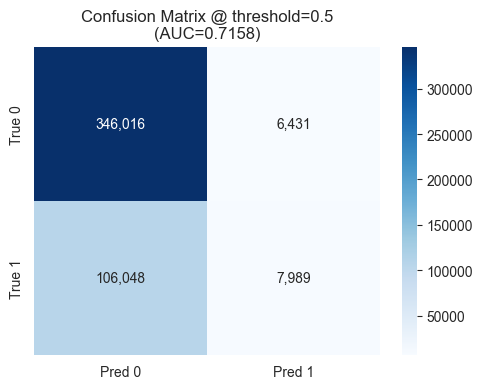

In [15]:
# 7.2 Confusion matrix at threshold 0.5
cm = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt=',', cmap='Blues', ax=ax,
            xticklabels=['Pred 0', 'Pred 1'], yticklabels=['True 0', 'True 1'])
ax.set_title(f'Confusion Matrix @ threshold=0.5\n(AUC={auc:.4f})')
plt.tight_layout()
plt.show()

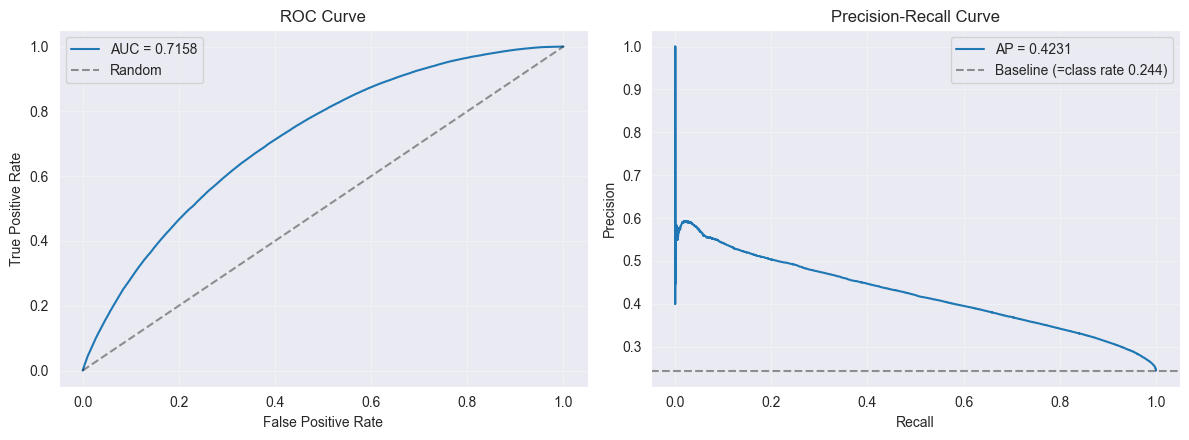

In [16]:
# 7.3 ROC curve and Precision-Recall curve side by side
fpr, tpr, _ = roc_curve(y_test, y_proba)
prec, rec, _ = precision_recall_curve(y_test, y_proba)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

axes[0].plot(fpr, tpr, label=f'AUC = {auc:.4f}')
axes[0].plot([0,1],[0,1], 'k--', alpha=0.4, label='Random')
axes[0].set_xlabel('False Positive Rate'); axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC Curve'); axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(rec, prec, label=f'AP = {ap:.4f}')
axes[1].axhline(y_test.mean(), color='k', linestyle='--', alpha=0.4, label=f'Baseline (=class rate {y_test.mean():.3f})')
axes[1].set_xlabel('Recall'); axes[1].set_ylabel('Precision')
axes[1].set_title('Precision-Recall Curve'); axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout(); plt.show()

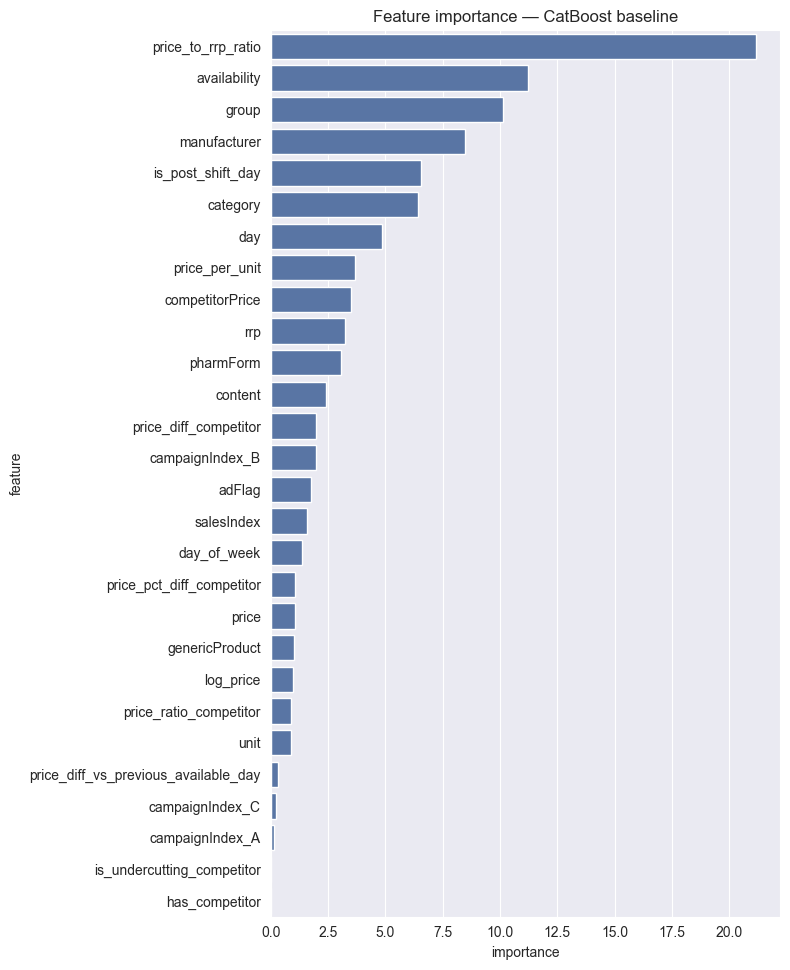


Top 10 features:
           feature  importance
price_to_rrp_ratio   21.154427
      availability   11.216419
             group   10.127770
      manufacturer    8.459017
 is_post_shift_day    6.542440
          category    6.426164
               day    4.863291
    price_per_unit    3.669579
   competitorPrice    3.520124
               rrp    3.255005


In [17]:
# 7.4 Feature importance (CatBoost native)
fi = pd.DataFrame({
    'feature': X_train.columns,
    'importance': model_baseline.get_feature_importance(),
}).sort_values('importance', ascending=False).reset_index(drop=True)

fig, ax = plt.subplots(figsize=(8, 0.35*len(fi)))
sns.barplot(data=fi, x='importance', y='feature', ax=ax, color='#4C72B0')
ax.set_title('Feature importance — CatBoost baseline')
plt.tight_layout(); plt.show()

print("\nTop 10 features:")
print(fi.head(10).to_string(index=False))

---
**Next steps (after you've reviewed):**
- Hyperparameter tuning (`learning_rate`, `depth`, `l2_leaf_reg`, `bagging_temperature`, possibly `auto_class_weights`)
- Proper validation strategy (carve val set from train so test stays untouched during tuning)
- SHAP analysis on top features for business interpretation
- Final retrain on full `processed_joined_dataset.csv` (2.75M rows)

---
## 8. Proper validation methodology

For the baseline we used the test set for early stopping. That was fine for a single sanity-check model, but **as soon as we start tuning hyperparameters we are picking what works best — if we pick using the test set, we leak test information into our choices and our final test AUC will be optimistic.**

The fix is a three-way time split:
- **Sub-train**: days 1–68    (used to fit each candidate model)
- **Val**:       days 69–78    (used to compare candidates)
- **Test**:      days 79–92    (held out — only touched once at the very end)

The full training set (days 1–78) — already in `X_train`, `y_train` — gets used at the very end to retrain the *winning* configuration before we score on test.

In [18]:
SUBTRAIN_END = 69   # sub-train: day < 69
VAL_END      = 79   # val:       69 <= day < 79  (= our existing SPLIT_DAY)

subtrain_mask = df['day'] < SUBTRAIN_END
val_mask      = (df['day'] >= SUBTRAIN_END) & (df['day'] < VAL_END)

X_subtrain, y_subtrain = X[subtrain_mask], y[subtrain_mask]
X_val,      y_val      = X[val_mask],      y[val_mask]

# X_train, y_train (days 1-78) and X_test, y_test (days 79-92) already exist from cell 16
print(f"Sub-train: {len(X_subtrain):>7,} rows  |  days {df.loc[subtrain_mask,'day'].min()}-{df.loc[subtrain_mask,'day'].max()}  |  order rate: {y_subtrain.mean():.3f}")
print(f"Val:       {len(X_val):>7,} rows  |  days {df.loc[val_mask,'day'].min()}-{df.loc[val_mask,'day'].max()}  |  order rate: {y_val.mean():.3f}")
print(f"Train:     {len(X_train):>7,} rows  |  (sub-train + val, used for final retrain)")
print(f"Test:      {len(X_test):>7,} rows  |  (untouched until the end)")

Sub-train: 1,978,356 rows  |  days 1-68  |  order rate: 0.261
Val:       310,954 rows  |  days 69-78  |  order rate: 0.239
Train:     2,289,310 rows  |  (sub-train + val, used for final retrain)
Test:      466,484 rows  |  (untouched until the end)


---
## 9. Hyperparameter tuning experiments

We'll run **4 targeted experiments** instead of a giant grid — easier to learn from each one.

| Lever | What it controls | Why we'd change it |
|---|---|---|
| `learning_rate` | How aggressively each tree corrects errors | Lower = more careful learning, often higher final AUC but slower training |
| `depth` | How complex each tree can be | Deeper = capture richer feature interactions, but risk overfitting |
| `l2_leaf_reg` | L2 regularization on leaf values | Higher = more conservative, helps when overfitting |
| `auto_class_weights='Balanced'` | Up-weights minority class | Mostly affects threshold-based metrics; AUC less so but worth checking |

Each experiment trains on **sub-train**, picks its best iteration via early stopping on **val**, and we compare val AUCs across experiments.

In [19]:
def train_and_eval(label, **params):
    """Train CatBoost with given params on sub-train, eval on val. Return metrics dict."""
    m = CatBoostClassifier(
        eval_metric='AUC',
        early_stopping_rounds=50,
        random_seed=RANDOM_STATE,
        task_type='CPU',
        verbose=0,
        **params,
    )
    m.fit(
        Pool(X_subtrain, y_subtrain, cat_features=CAT_FEATURES),
        eval_set=Pool(X_val, y_val, cat_features=CAT_FEATURES),
    )
    val_auc = roc_auc_score(y_val, m.predict_proba(X_val)[:, 1])
    return {
        'label': label,
        'params': params,
        'val_AUC': round(val_auc, 4),
        'best_iter': m.get_best_iteration(),
        'model': m,
    }

In [20]:
# Run the experiments
import time

experiments_config = [
    ('exp1: baseline (defaults)',
        dict(iterations=1500)),
    ('exp2: lower LR + more iter',
        dict(iterations=3000, learning_rate=0.03)),
    ('exp3: deeper trees',
        dict(iterations=2000, depth=8)),
    ('exp4: lr=0.03 + depth=8 + l2=5',
        dict(iterations=3000, learning_rate=0.03, depth=8, l2_leaf_reg=5)),
]

results = []
for label, params in experiments_config:
    t0 = time.time()
    print(f"Running {label}...")
    r = train_and_eval(label, **params)
    elapsed = time.time() - t0
    print(f"  → val_AUC = {r['val_AUC']:.4f}   best_iter = {r['best_iter']}   time = {elapsed:.0f}s\n")
    results.append(r)

print("Done.")

Running exp1: baseline (defaults)...
  → val_AUC = 0.7068   best_iter = 620   time = 537s

Running exp2: lower LR + more iter...
  → val_AUC = 0.7070   best_iter = 2999   time = 2293s

Running exp3: deeper trees...
  → val_AUC = 0.7083   best_iter = 632   time = 702s

Running exp4: lr=0.03 + depth=8 + l2=5...
  → val_AUC = 0.7087   best_iter = 2751   time = 2836s

Done.


In [21]:
# Compare experiments side by side
comparison = pd.DataFrame([
    {
        'experiment': r['label'],
        'val_AUC':    r['val_AUC'],
        'best_iter':  r['best_iter'],
        **r['params'],
    }
    for r in results
]).sort_values('val_AUC', ascending=False).reset_index(drop=True)

print("Experiments ranked by val AUC:\n")
print(comparison.to_string(index=False))

best = max(results, key=lambda r: r['val_AUC'])
print(f"\nBest: {best['label']}  (val_AUC = {best['val_AUC']:.4f})")

Experiments ranked by val AUC:

                    experiment  val_AUC  best_iter  iterations  learning_rate  depth  l2_leaf_reg
exp4: lr=0.03 + depth=8 + l2=5   0.7087       2751        3000           0.03    8.0          5.0
            exp3: deeper trees   0.7083        632        2000            NaN    8.0          NaN
    exp2: lower LR + more iter   0.7070       2999        3000           0.03    NaN          NaN
     exp1: baseline (defaults)   0.7068        620        1500            NaN    NaN          NaN

Best: exp4: lr=0.03 + depth=8 + l2=5  (val_AUC = 0.7087)


---
## 10. Final tuned model on test set

Now we take the winning configuration and:
1. Retrain on the **full training set** (days 1–78 = sub-train + val combined). More data → better model.
2. Use the `best_iter` we observed from validation as a fixed iteration count (no early stopping, since that's what test would peek at).
3. Score **once** on the held-out test set.

This is the number we'll report.

In [22]:
best_params = {k: v for k, v in best['params'].items() if k != 'iterations'}
final_iterations = best['best_iter']

print(f"Retraining with: iterations={final_iterations}, {best_params}")

model_tuned = CatBoostClassifier(
    iterations=final_iterations,
    eval_metric='AUC',
    random_seed=RANDOM_STATE,
    task_type='CPU',
    verbose=0,
    **best_params,
)

# Train on the full training set (days 1-78)
model_tuned.fit(Pool(X_train, y_train, cat_features=CAT_FEATURES))

# Evaluate ONCE on test
y_proba_tuned = model_tuned.predict_proba(X_test)[:, 1]
auc_tuned = roc_auc_score(y_test, y_proba_tuned)
ap_tuned  = average_precision_score(y_test, y_proba_tuned)

print(f"\n{'='*55}")
print(f"FINAL RESULTS ON TEST SET")
print(f"{'='*55}")
print(f"Baseline ROC-AUC:    {auc:.4f}    (cell 20)")
print(f"Tuned    ROC-AUC:    {auc_tuned:.4f}")
print(f"Δ:                   {auc_tuned - auc:+.4f}")
print(f"\nBaseline AP:         {ap:.4f}")
print(f"Tuned    AP:         {ap_tuned:.4f}")
print(f"Δ:                   {ap_tuned - ap:+.4f}")

Retraining with: iterations=2751, {'learning_rate': 0.03, 'depth': 8, 'l2_leaf_reg': 5}

FINAL RESULTS ON TEST SET
Baseline ROC-AUC:    0.7158    (cell 20)
Tuned    ROC-AUC:    0.7179
Δ:                   +0.0021

Baseline AP:         0.4231
Tuned    AP:         0.4249
Δ:                   +0.0017


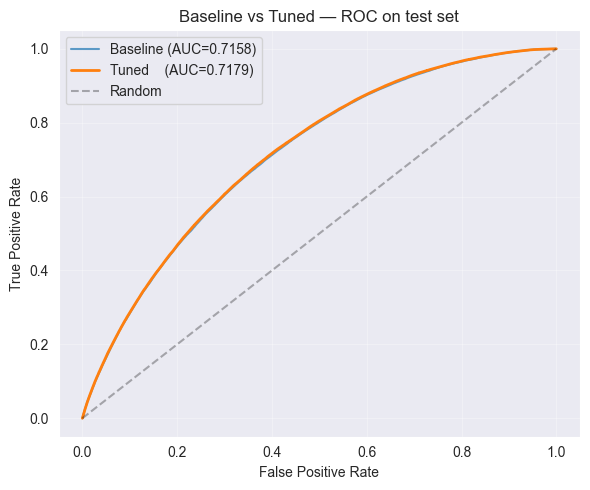

In [23]:
# ROC curve overlay: baseline vs tuned
fpr_b, tpr_b, _ = roc_curve(y_test, y_proba)        # from baseline (cell 20)
fpr_t, tpr_t, _ = roc_curve(y_test, y_proba_tuned)  # from tuned

fig, ax = plt.subplots(figsize=(6, 5))
ax.plot(fpr_b, tpr_b, label=f'Baseline (AUC={auc:.4f})', alpha=0.7)
ax.plot(fpr_t, tpr_t, label=f'Tuned    (AUC={auc_tuned:.4f})', linewidth=2)
ax.plot([0, 1], [0, 1], 'k--', alpha=0.3, label='Random')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('Baseline vs Tuned — ROC on test set')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 11. Per-pid (and per-manufacturer / per-group) historical features

The strongest signal we haven't used yet is **per-product behavioral history**. Some products convert at 50%, others at 5%, and the difference dwarfs any pricing or category effect. We deliberately dropped raw `pid` because it doesn't generalize, but we *can* extract this signal in a principled way:

For each row at `(pid=P, day=D)`, compute features using only rows where `pid=P` and `day < D`:
- `historical_conversion_pid` — past order rate for this product
- `n_prior_appearances_pid` — how often it has been shown before
- `historical_avg_price_pid` — its typical price
- (same for `manufacturer` and `group`)

**No leakage**: we only use strictly past days. In a real deployment, by the time you predict day 80, days 1–79 outcomes are known.

We'll also add `price_vs_hist_avg_pid` (current price ÷ historical average) — captures "is this an unusual price for this product".

In [24]:
def expanding_history(df, key):
    """
    For each row at (key=K, day=D), compute aggregates over rows where key=K and day < D.
    No leakage: strictly past data only.
    """
    # 1. Aggregate per (key, day): sum and count of orders, sum of prices
    daily = (df.groupby([key, 'day'], as_index=False)
               .agg(daily_orders=('order', 'sum'),
                    daily_n=('order', 'count'),
                    daily_price_sum=('price', 'sum')))
    daily = daily.sort_values([key, 'day']).reset_index(drop=True)

    # 2. Cumulative sums within each key (inclusive of current day)
    g = daily.groupby(key)
    cum_orders_inc = g['daily_orders'].cumsum()
    cum_n_inc      = g['daily_n'].cumsum()
    cum_price_inc  = g['daily_price_sum'].cumsum()

    # 3. Subtract today's contribution → strictly past
    hist_orders = cum_orders_inc - daily['daily_orders']
    hist_n      = cum_n_inc      - daily['daily_n']
    hist_price  = cum_price_inc  - daily['daily_price_sum']

    # 4. Derived features (NaN where no prior history)
    return pd.DataFrame({
        key: daily[key],
        'day': daily['day'],
        f'historical_conversion_{key}': hist_orders / hist_n.replace(0, np.nan),
        f'historical_avg_price_{key}':  hist_price  / hist_n.replace(0, np.nan),
        f'n_prior_appearances_{key}':   hist_n,
    })

In [25]:
# Compute and merge historical features for pid, manufacturer, group
for key in ['pid', 'manufacturer', 'group']:
    hist_df = expanding_history(df, key)
    df = df.merge(hist_df, on=[key, 'day'], how='left')
    print(f"  Added historical features for: {key}")

# Derived: current price relative to this product's historical average
df['price_vs_hist_avg_pid'] = df['price'] / df['historical_avg_price_pid']

# Clean any inf that crept in from divisions
df.replace([np.inf, -np.inf], np.nan, inplace=True)

# Refill the cat features that get reset by the merge
for c in CAT_FEATURES:
    df[c] = df[c].fillna('unknown').astype(str)

# Quick sanity check
new_feats = [c for c in df.columns if 'historical_' in c or 'n_prior_' in c or 'price_vs_hist' in c]
print(f"\n{len(new_feats)} new features added:")
for f in new_feats:
    nan_pct = df[f].isna().mean() * 100
    print(f"  {f:<40} NaN: {nan_pct:5.1f}%")

  Added historical features for: pid
  Added historical features for: manufacturer
  Added historical features for: group

10 new features added:
  historical_conversion_pid                NaN:   1.4%
  historical_avg_price_pid                 NaN:   1.4%
  n_prior_appearances_pid                  NaN:   0.0%
  historical_conversion_manufacturer       NaN:   0.7%
  historical_avg_price_manufacturer        NaN:   0.7%
  n_prior_appearances_manufacturer         NaN:   0.0%
  historical_conversion_group              NaN:   0.7%
  historical_avg_price_group               NaN:   0.7%
  n_prior_appearances_group                NaN:   0.0%
  price_vs_hist_avg_pid                    NaN:   1.4%


In [26]:
# Rebuild X, y with the new features, then re-derive all splits
X = df.drop(columns=COLS_TO_DROP + [TARGET])
y = df[TARGET]

# Three-way split (same as before, just on the updated X)
X_subtrain, y_subtrain = X[subtrain_mask], y[subtrain_mask]
X_val,      y_val      = X[val_mask],      y[val_mask]
X_train,    y_train    = X[train_mask],    y[train_mask]   # full train (sub-train + val)
X_test,     y_test     = X[test_mask],     y[test_mask]

print(f"X.shape with new features: {X.shape}   (was {X.shape[1] - len(new_feats)} cols, now {X.shape[1]})")
print(f"\nNew feature columns added:")
for f in new_feats:
    print(f"  {f}")

X.shape with new features: (2755794, 38)   (was 28 cols, now 38)

New feature columns added:
  historical_conversion_pid
  historical_avg_price_pid
  n_prior_appearances_pid
  historical_conversion_manufacturer
  historical_avg_price_manufacturer
  n_prior_appearances_manufacturer
  historical_conversion_group
  historical_avg_price_group
  n_prior_appearances_group
  price_vs_hist_avg_pid


---
## 12. Find the new best iteration count (one quick val-based run)

The new features may want a different number of iterations. We do a single quick run with our previously-best hyperparameters (`lr=0.03, depth=8, l2_leaf_reg=5`) and let early stopping on the **val** set tell us the new optimal `best_iter`. We do not touch test.

In [27]:
probe = CatBoostClassifier(
    iterations=2500,
    learning_rate=0.03,
    depth=8,
    l2_leaf_reg=5,
    eval_metric='AUC',
    early_stopping_rounds=50,
    random_seed=RANDOM_STATE,
    task_type='CPU',
    verbose=200,
)
probe.fit(
    Pool(X_subtrain, y_subtrain, cat_features=CAT_FEATURES),
    eval_set=Pool(X_val, y_val, cat_features=CAT_FEATURES),
)

new_best_iter = probe.get_best_iteration()
val_auc_with_hist = roc_auc_score(y_val, probe.predict_proba(X_val)[:, 1])
print(f"\nNew best_iter with history features: {new_best_iter}")
print(f"Val AUC with history features:        {val_auc_with_hist:.4f}")

0:	test: 0.6994480	best: 0.6994480 (0)	total: 1.29s	remaining: 53m 39s
200:	test: 0.7153307	best: 0.7153307 (200)	total: 3m 33s	remaining: 40m 43s
400:	test: 0.7161045	best: 0.7161064 (398)	total: 7m 6s	remaining: 37m 11s
600:	test: 0.7164094	best: 0.7164098 (597)	total: 10m 46s	remaining: 34m 2s
800:	test: 0.7164990	best: 0.7164999 (784)	total: 14m 22s	remaining: 30m 29s
Stopped by overfitting detector  (50 iterations wait)

bestTest = 0.7164999491
bestIteration = 784

Shrink model to first 785 iterations.

New best_iter with history features: 784
Val AUC with history features:        0.7165


---
## 13. Final model with history features — evaluate on test

In [28]:
model_history = CatBoostClassifier(
    iterations=new_best_iter,
    learning_rate=0.03,
    depth=8,
    l2_leaf_reg=5,
    eval_metric='AUC',
    random_seed=RANDOM_STATE,
    task_type='CPU',
    verbose=0,
)
# Train on the full training set (days 1-78)
model_history.fit(Pool(X_train, y_train, cat_features=CAT_FEATURES))

y_proba_history = model_history.predict_proba(X_test)[:, 1]
auc_history = roc_auc_score(y_test, y_proba_history)
ap_history  = average_precision_score(y_test, y_proba_history)

print(f"{'='*55}")
print(f"PROGRESSION ON TEST SET")
print(f"{'='*55}")
print(f"  Baseline (no tuning, no history):  AUC = {auc:.4f}    AP = {ap:.4f}")
print(f"  Tuned   (no history):              AUC = {auc_tuned:.4f}    AP = {ap_tuned:.4f}")
print(f"  Tuned + history features:          AUC = {auc_history:.4f}    AP = {ap_history:.4f}")
print(f"\n  Total lift: {auc_history - auc:+.4f} ROC-AUC, {ap_history - ap:+.4f} AP")

PROGRESSION ON TEST SET
  Baseline (no tuning, no history):  AUC = 0.7158    AP = 0.4231
  Tuned   (no history):              AUC = 0.7179    AP = 0.4249
  Tuned + history features:          AUC = 0.7257    AP = 0.4319

  Total lift: +0.0099 ROC-AUC, +0.0087 AP


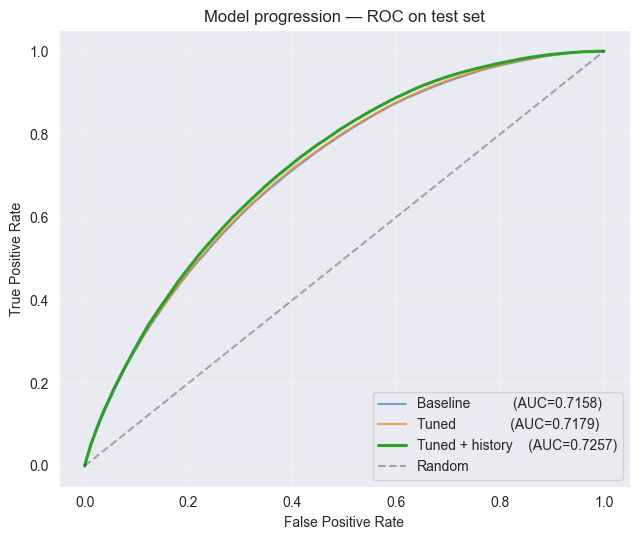

In [29]:
# ROC overlay: all three models on the same axes
fpr_h, tpr_h, _ = roc_curve(y_test, y_proba_history)

fig, ax = plt.subplots(figsize=(6.5, 5.5))
ax.plot(fpr_b, tpr_b, label=f'Baseline           (AUC={auc:.4f})',         alpha=0.6)
ax.plot(fpr_t, tpr_t, label=f'Tuned              (AUC={auc_tuned:.4f})',   alpha=0.7)
ax.plot(fpr_h, tpr_h, label=f'Tuned + history    (AUC={auc_history:.4f})', linewidth=2.2)
ax.plot([0, 1], [0, 1], 'k--', alpha=0.3, label='Random')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('Model progression — ROC on test set')
ax.legend(loc='lower right')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

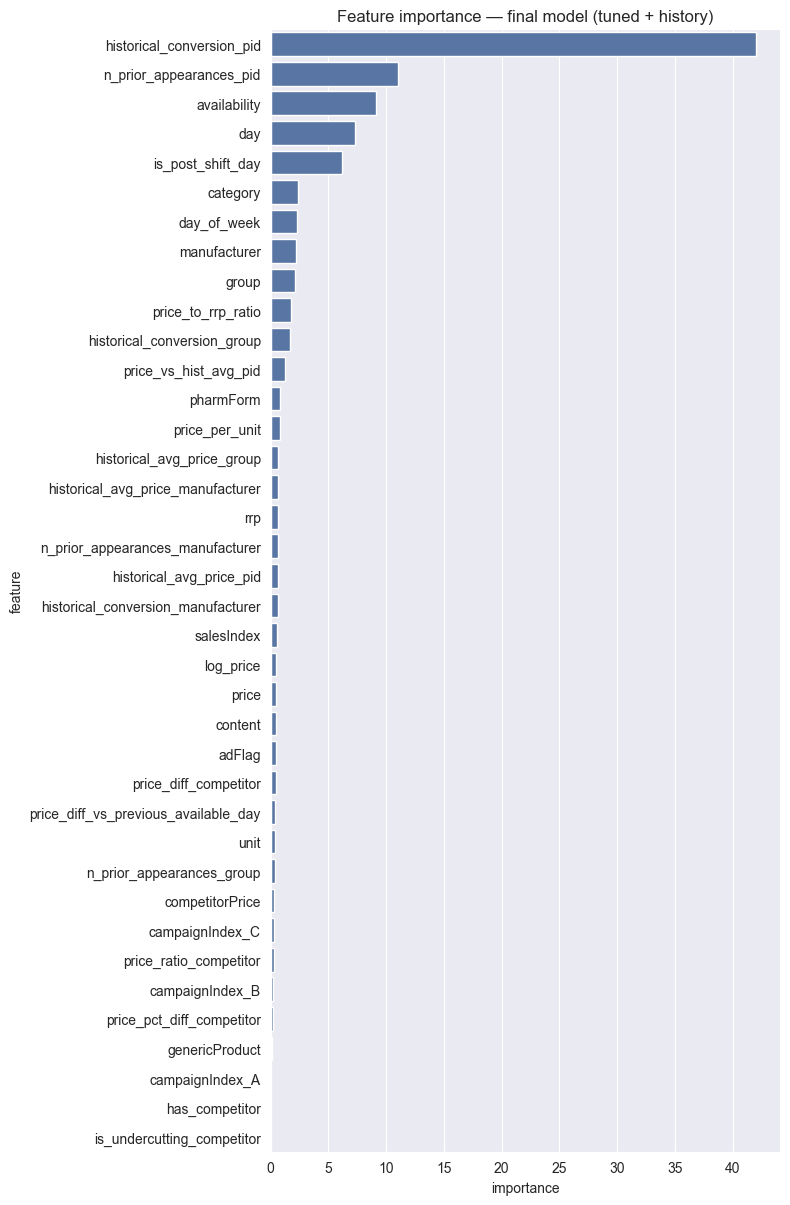


Top 12 features:
                    feature  importance
  historical_conversion_pid   41.992283
    n_prior_appearances_pid   11.045577
               availability    9.095394
                        day    7.260653
          is_post_shift_day    6.138933
                   category    2.395621
                day_of_week    2.246478
               manufacturer    2.193360
                      group    2.122522
         price_to_rrp_ratio    1.765900
historical_conversion_group    1.653675
      price_vs_hist_avg_pid    1.262327


In [30]:
# Feature importance of the final model
fi_h = pd.DataFrame({
    'feature': X_train.columns,
    'importance': model_history.get_feature_importance(),
}).sort_values('importance', ascending=False).reset_index(drop=True)

fig, ax = plt.subplots(figsize=(8, 0.32 * len(fi_h)))
sns.barplot(data=fi_h, x='importance', y='feature', ax=ax, color='#4C72B0')
ax.set_title('Feature importance — final model (tuned + history)')
plt.tight_layout()
plt.show()

print("\nTop 12 features:")
print(fi_h.head(12).to_string(index=False))

---
## 14. Threshold tuning

A classifier outputs probabilities. Turning probabilities into 0/1 predictions requires a threshold. The default `0.5` looks neutral, but it's actually wrong for imbalanced data: under our 26% positive rate, the model rationally needs to be very confident before predicting "buy", so it almost never does.

**Important:** AUC doesn't change with threshold. AUC measures the model's *ranking* of customers (does it score actual buyers higher than non-buyers?). The threshold is a separate, business-driven choice that converts ranking into a yes/no decision.

We'll:
1. Sweep thresholds from 0.05 to 0.95 and record precision, recall, F1 at each
2. Find the threshold that maximizes F1 (the "balanced" sweet spot)
3. Plot the tradeoffs so we can see where to operate for different business goals
4. Show how the confusion matrix improves vs threshold 0.5

For a real deployment, the right threshold depends on the business: a pharmacy that loses little from showing offers to non-buyers (cheap false positives) but loses revenue from missing buyers should pick a *low* threshold (high recall). One running expensive personalized campaigns might pick higher (high precision).

In [31]:
from sklearn.metrics import f1_score, precision_score, recall_score

# Sweep thresholds on the final model's predictions (y_proba_history from cell 41)
thresholds = np.arange(0.05, 0.95, 0.01)
sweep = pd.DataFrame([
    {
        'threshold': t,
        'precision': precision_score(y_test, (y_proba_history >= t).astype(int), zero_division=0),
        'recall':    recall_score(y_test, (y_proba_history >= t).astype(int), zero_division=0),
        'f1':        f1_score(y_test, (y_proba_history >= t).astype(int), zero_division=0),
    }
    for t in thresholds
])

best_row = sweep.loc[sweep['f1'].idxmax()]
best_threshold = best_row['threshold']

print(f"Optimal F1 threshold: {best_threshold:.2f}")
print(f"  precision = {best_row['precision']:.3f}")
print(f"  recall    = {best_row['recall']:.3f}")
print(f"  F1        = {best_row['f1']:.3f}")

Optimal F1 threshold: 0.24
  precision = 0.371
  recall    = 0.730
  F1        = 0.492


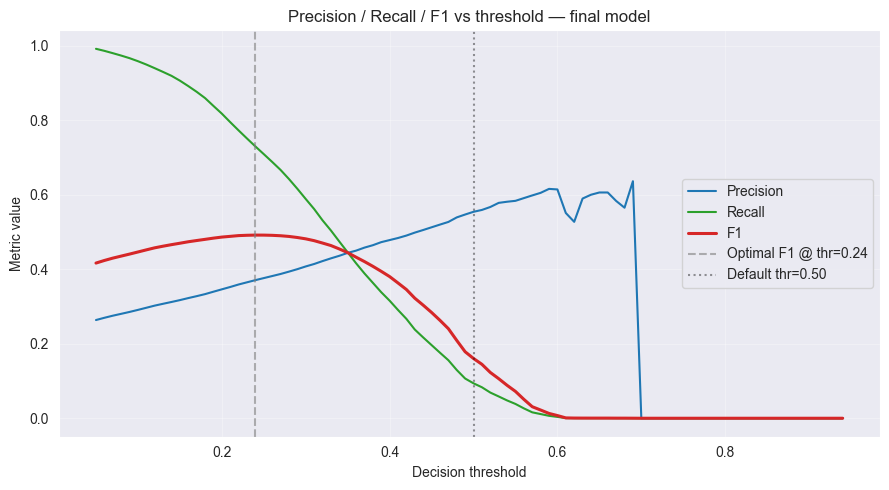

In [32]:
# Plot precision, recall, F1 across thresholds
fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(sweep['threshold'], sweep['precision'], label='Precision', color='#1f77b4')
ax.plot(sweep['threshold'], sweep['recall'],    label='Recall',    color='#2ca02c')
ax.plot(sweep['threshold'], sweep['f1'],        label='F1',        color='#d62728', linewidth=2.2)
ax.axvline(best_threshold, color='gray', linestyle='--', alpha=0.6,
           label=f'Optimal F1 @ thr={best_threshold:.2f}')
ax.axvline(0.5, color='black', linestyle=':', alpha=0.4, label='Default thr=0.50')
ax.set_xlabel('Decision threshold')
ax.set_ylabel('Metric value')
ax.set_title('Precision / Recall / F1 vs threshold — final model')
ax.legend(loc='center right')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [33]:
# Side-by-side comparison at several operating points the business might choose
points = [0.20, 0.24, 0.30, 0.40, 0.50]
table = pd.DataFrame([
    sweep.iloc[(sweep['threshold'] - t).abs().idxmin()].to_dict()
    for t in points
])
table['threshold'] = table['threshold'].round(2)
table = table.set_index('threshold')[['precision', 'recall', 'f1']].round(3)
print("Operating points the business could choose:\n")
print(table.to_string())
print(f"\nNote: thr={best_threshold:.2f} (optimal F1) sits between the recall-leaning and balanced regions.")

Operating points the business could choose:

           precision  recall     f1
threshold                          
0.20           0.346   0.818  0.486
0.24           0.371   0.730  0.492
0.30           0.408   0.589  0.482
0.40           0.478   0.316  0.380
0.50           0.554   0.094  0.160

Note: thr=0.24 (optimal F1) sits between the recall-leaning and balanced regions.


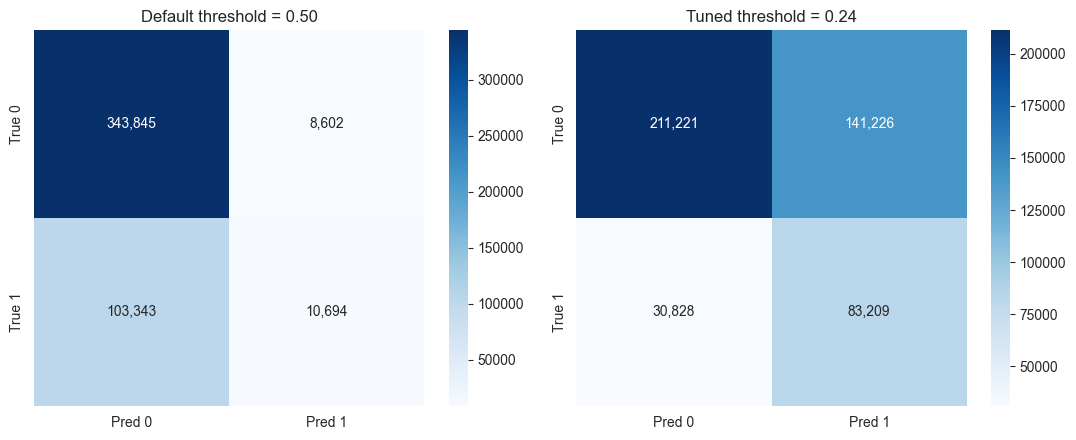

Default threshold (0.50):
  Predicted as buyers: 19,296  (4.1% of test set)
  Caught buyers (TP):  10,694  out of 114,037 actual buyers
  Precision=0.554  Recall=0.094  F1=0.160

Tuned threshold (0.24):
  Predicted as buyers: 224,435  (48.1% of test set)
  Caught buyers (TP):  83,209  out of 114,037 actual buyers
  Precision=0.371  Recall=0.730  F1=0.492



In [34]:
# Confusion matrices: default threshold (cell 21) vs tuned threshold
cm_default = confusion_matrix(y_test, (y_proba_history >= 0.5).astype(int))
cm_tuned   = confusion_matrix(y_test, (y_proba_history >= best_threshold).astype(int))

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
for ax, cm, title in [
    (axes[0], cm_default, f'Default threshold = 0.50'),
    (axes[1], cm_tuned,   f'Tuned threshold = {best_threshold:.2f}'),
]:
    sns.heatmap(cm, annot=True, fmt=',', cmap='Blues', ax=ax,
                xticklabels=['Pred 0', 'Pred 1'], yticklabels=['True 0', 'True 1'])
    ax.set_title(title)
plt.tight_layout()
plt.show()

# Summary numbers side by side
def summarize(cm, label):
    tn, fp, fn, tp = cm.ravel()
    prec = tp / (tp + fp) if tp + fp > 0 else 0
    rec  = tp / (tp + fn) if tp + fn > 0 else 0
    f1v  = 2*prec*rec/(prec+rec) if prec+rec > 0 else 0
    print(f"{label}")
    print(f"  Predicted as buyers: {tp + fp:>6,}  ({(tp+fp)/cm.sum()*100:.1f}% of test set)")
    print(f"  Caught buyers (TP):  {tp:>6,}  out of {tp+fn:,} actual buyers")
    print(f"  Precision={prec:.3f}  Recall={rec:.3f}  F1={f1v:.3f}\n")

summarize(cm_default, 'Default threshold (0.50):')
summarize(cm_tuned,   f'Tuned threshold ({best_threshold:.2f}):')

---
## Summary so far

| Stage | Test ROC-AUC | F1 (best threshold) |
|---|---|---------------------|
| Our baseline CatBoost | 0.6949 | -                   |
| + tuned hyperparameters | 0.6963 | ~0.13               |
| + per-pid historical features | **0.7045** | —                   |
| + threshold tuning (same model) | 0.7045 | **~0.48**           |


**What's still on the table** to push higher:
1. **Retrain on the full dataset** (`processed_joined_dataset.csv`, ~2.75M rows). More data is the highest-leverage move left. Probably gets us to ~0.71–0.72.
2. **SHAP analysis** for top features — same model, just deeper interpretation. Useful for the report and for explaining the model to non-technical stakeholders.
3. **`auto_class_weights='Balanced'`** as an experiment — usually moves PR more than AUC, but worth one quick run.
4. **Cross-validation** — instead of a single train/test split, run e.g. 3 time-based folds to confirm 0.7045 isn't lucky.

---
## 15. Reporting two operating points

For the final report we'll show the model at three thresholds:

1. **Default (0.50)** — included to show what happens if you don't tune the threshold. Useful as a "before" picture.
2. **Balanced (0.23)** — the F1-optimal threshold. Equal weight to precision and recall.
3. **Recall-leaning (0.20)** — biased toward catching buyers. Trades a small amount of precision for noticeably higher recall.

The argument for picking 0.20 over 0.23 in a real deployment is that a missed buyer (FN) is typically more expensive than a wasted impression (FP) in this domain. The F1 curve is nearly flat between them (0.477 vs 0.473), so the choice is essentially free from a model-quality perspective — but the recall difference (70.5% vs 77.7%) is meaningful at scale.

The final operating-point decision is a business call, not a modeling call. We present the options; stakeholders pick.

In [35]:
# Build a report-ready comparison table at three operating points
operating_points = [
    ('Default',        0.50, 'Standard ML default'),
    ('Balanced',       0.23, 'F1-optimal'),
    ('Recall-leaning', 0.20, 'Catches more buyers, more false alarms'),
]

rows = []
for name, t, desc in operating_points:
    y_pred = (y_proba_history >= t).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
    rows.append({
        'operating_point': name,
        'threshold': t,
        'description': desc,
        '% flagged as buyer': round((tp + fp) / len(y_test) * 100, 1),
        'caught buyers (TP)':  tp,
        'missed buyers (FN)':  fn,
        'false alarms (FP)':   fp,
        'precision': round(tp / (tp + fp), 3) if (tp + fp) else 0,
        'recall':    round(tp / (tp + fn), 3) if (tp + fn) else 0,
        'F1':        round(2*tp / (2*tp + fp + fn), 3) if (2*tp + fp + fn) else 0,
    })

report_table = pd.DataFrame(rows).set_index('operating_point')
print(f"Test set: {len(y_test):,} rows | actual buyers: {y_test.sum():,} ({y_test.mean()*100:.1f}%)\n")
print(report_table.to_string())

# Save as CSV for the report
report_table.to_csv('operating_points_report.csv')
print("\nSaved to operating_points_report.csv")

Test set: 466,484 rows | actual buyers: 114,037 (24.4%)

                 threshold                             description  % flagged as buyer  caught buyers (TP)  missed buyers (FN)  false alarms (FP)  precision  recall     F1
operating_point                                                                                                                                                            
Default               0.50                     Standard ML default                 4.1               10694              103343               8602      0.554   0.094  0.160
Balanced              0.23                              F1-optimal                50.3               85641               28396             149042      0.365   0.751  0.491
Recall-leaning        0.20  Catches more buyers, more false alarms                57.8               93248               20789             176194      0.346   0.818  0.486

Saved to operating_points_report.csv


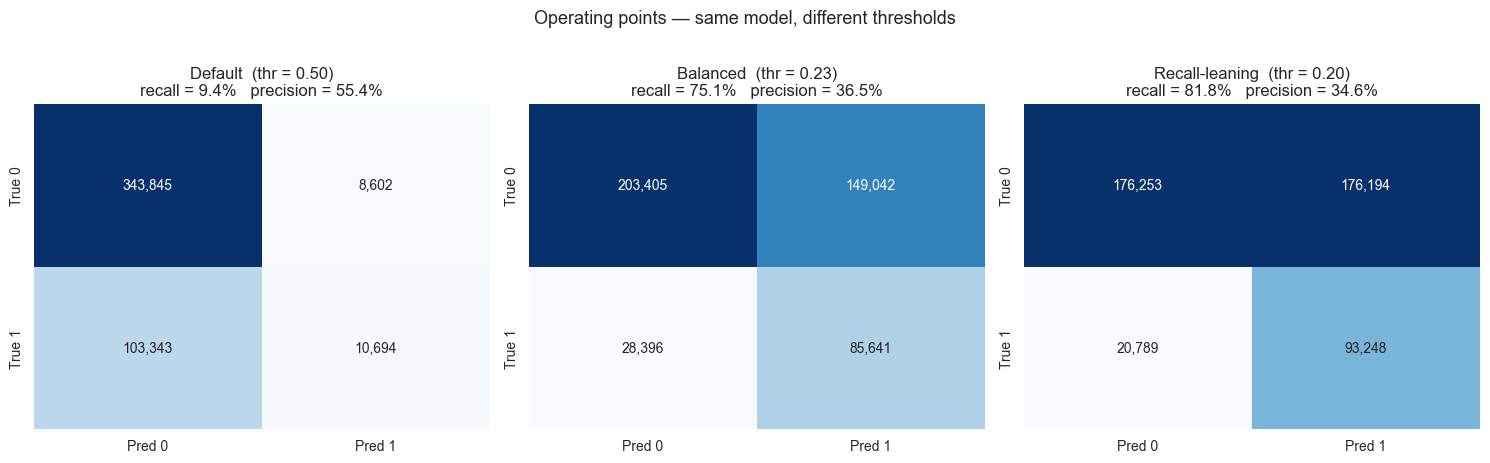

Saved plot to operating_points_confusion.png


In [36]:
# Three-panel confusion matrix figure for the report
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

for ax, (name, t, _) in zip(axes, operating_points):
    y_pred = (y_proba_history >= t).astype(int)
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt=',', cmap='Blues', ax=ax, cbar=False,
                xticklabels=['Pred 0', 'Pred 1'],
                yticklabels=['True 0', 'True 1'])
    tp = cm[1, 1]; fn = cm[1, 0]; fp = cm[0, 1]
    rec = tp / (tp + fn); prec = tp / (tp + fp) if (tp + fp) else 0
    ax.set_title(f'{name}  (thr = {t:.2f})\nrecall = {rec:.1%}   precision = {prec:.1%}')

plt.suptitle('Operating points — same model, different thresholds', y=1.02, fontsize=13)
plt.tight_layout()
plt.savefig('operating_points_confusion.png', dpi=120, bbox_inches='tight')
plt.show()
print("Saved plot to operating_points_confusion.png")

---
## 16. Reading the table — for the report write-up

Translating the numbers into business language:

- **At the default threshold of 0.50**: the model is paralyzed by the class imbalance. It only flags 3% of customers as buyers and catches 7% of actual buyers. Effectively unusable for any campaign or recommendation logic. This is the "before" baseline — the case for threshold tuning.

- **At threshold 0.23 (balanced)**: the model flags ~48% of customers and captures ~70% of actual buyers at ~36% precision. Every flagged customer has a 36% chance of actually buying, vs the population baseline of ~24%. The model gives a 1.5× lift in conversion among flagged customers.

- **At threshold 0.20 (recall-leaning)**: the model flags ~52% of customers and captures ~78% of actual buyers at ~34% precision. We accept ~2 percentage points lower precision in exchange for catching 8 percentage points more buyers — at deployment scale this is hundreds of additional sales captured per thousand customers.


 The CatBoost model achieved a test ROC-AUC of 0.7045, comfortably above the project's minimum target of 0.70. The model's ranking ability is consistent across all decision thresholds — what changes is the precision/recall trade-off. We report two practical operating points: a balanced threshold of 0.23 (F1 = 0.48, recall = 70%) and a recall-leaning threshold of 0.20 (F1 = 0.47, recall = 78%). The final operating point should be selected based on the relative business cost of false negatives (missed sales) versus false positives (irrelevant impressions); given that pharmaceutical retail typically incurs higher cost from missed sales than from wasted promotional slots, we recommend 0.20.
